# Project Euler 161-

I published 100+ solutions as I advocate ideas from [Stephan-brumme](https://euler.stephan-brumme.com/why/) and [IVL](https://www.ivl-projecteuler.com/)

In [ ]:
%run PE_Informatics/PE_pre_running.py # After I solved many questions, I found some functions repeated, eg.Prime-Check, Fibonacci

## 161-200

#### PE 162

In [ ]:
(* 162 Hexadecimal Numbers *)
lst=Table[(n-1)*Factorial[n-1]/Factorial[n-3]*(14^(n-3)),{n,3,16}];
lst1=Table[(n-1)*Factorial[n-1]/Factorial[n-3]*(16^(n-3)),{n,3,16}];
n=(Total[lst1]-Total[lst])/2;
n=
BaseForm[Total[lst]+n,16]

In [ ]:
d={0:'0',1:'1',2:'2',3:'3',4:'4',5:'5',6:'6',7:'7',8:'8',9:'9',10:'A',11:'B',12:'C',13:'D',14:'E',15:'F'}
ans=0
limit=16
for i in range(3,limit+1):
    count=15*16^(i-1)
    a0=15^i
    a1=14*15^(i-1)
    count-=a0
    count-=2*a1
    a01=14^i
    a1a=13*14^(i-1)
    count+=2*a01
    count+=a1a
    a01a=13^i
    count-=a01a
    ans+=count
lst=ZZ(ans).digits(base=16)[::-1]
ans=''
for num in lst:
    ans=ans+d[num]
print(ans)

#### PE 164

In [ ]:
# 164 Three Consecutive Digital Sum Limit
d={i:1 for i in range(10,100) if sum(map(int,str(i)))<=9}
new_d={i:0 for i in range(100) if sum(map(int,str(i)))<=9}
for _ in range(18):
    for num in d:
        s=sum(map(int,str(num)))
        num_left=9-s
        last_digit=str(num)[-1]
        for i in range(num_left+1):
            new_d.update({int(last_digit+str(i)):new_d[int(last_digit+str(i))]+d[num]})
    d=new_d
    new_d={i:0 for i in range(100) if sum(map(int,str(i)))<=9}
count=0
for num in d:
    count+=d[num]
count

#### PE 169(unfinished)

In [ ]:
# 169 Sum of Powers of Two(debug)
memo={}
def min_pos(num):
    for i in range(100):
        if 2^(i+2)-2>=num:
            return i
def memo_sum_of_powers_of_two(num,digit_used=0,max_num=40):
    if num<0: return 0
    elif num==0: return 1
    elif (num,digit_used,max_num) in memo: return memo[(num,digit_used,max_num)]
    ans=0
    for i in range(min_pos(num),max_num)[::-1]:
        ans+=memo_sum_of_powers_of_two(num-2^i,digit_used=1,max_num=i)
    if digit_used!=2: ans+=memo_sum_of_powers_of_two(num-2^max_num,digit_used=digit_used+1)
    memo[(num,digit_used,max_num)]=ans
    return ans
def sum_of_powers_of_two(num,max_num=100,digit_used=0):
    if num<0: return 0
    elif num==0: return 1
    ans=0
    for i in range(min_pos(num),max_num)[::-1]:
        ans+=sum_of_powers_of_two(num-2^i,i,1)
    if digit_used!=2: ans+=sum_of_powers_of_two(num-2^max_num,max_num,digit_used+1)
    return ans
def alt_memo_sum_of_powers_of_two(num,max_num=100,digit_used=0):
    if num<0: return 0
    elif num<=1: return 1
    elif (num,digit_used,max_num) in memo: return memo[(num,digit_used,max_num)]
    ans=0
    for i in range(min_pos(num),max_num)[::-1]:
        ans+=alt_memo_sum_of_powers_of_two(num-2^i,i,1)
    if digit_used!=2: ans+=alt_memo_sum_of_powers_of_two(num-2^max_num,max_num,digit_used+1)
    memo[(num,digit_used,max_num)]=ans
    return ans
alt_memo_sum_of_powers_of_two(10^25)

#### PE 173

In [ ]:
# 173 Hollow Square Laminae I
def laminae_count(max_tiles):
    count=0
    limit=isqrt(max_tiles/4)
    for i in range(1,limit+1):
        num=max_tiles
        num-=4*i^2
        num//=4*i
        count+=num
    return count

laminae_count(10^6)

#### PE 174

In [ ]:
# 174 Hollow Square Laminae II
def laminae_list(max_tiles):
    lst=[]
    limit=isqrt(max_tiles/4)
    for i in range(1,limit+1):
        num=max_tiles
        num-=4*i^2
        num//=4*i
        for j in range(1,num+1):
            lst.append(4*i^2+4*i*j)
    return sorted(lst)

lst=laminae_list(1000000)
val=0
count=0
for num in sorted(list(set(lst))):
    old_val=val
    val=lst[old_val:old_val+100].index(num)+old_val
    if 1<=val-old_val<=10:
        count+=1
count

#### PE 179

In [ ]:
# 179
def len_factors(n):
    return len(factors(n))
num=1
for i in range(3, 10000000):
    if is_prime(i)==True or is_prime(i+1)==True:
        pass
    else:
        if len_factors(i)==len_factors(i+1):
            num+=1
        if i%10000==0:
            print(i)
num

#### PE 182

In [ ]:
p=19
q=37
n=p*q
totient=(p-1)*(q-1)
unconcealed_brute_force(p,q,n,181,totient)

In [ ]:
p=19
q=37
e=181
1+gcd(e-1,p-1)+gcd(e-1,q-1)+gcd(e+1,p-1)

In [ ]:
# 182 RSA Encryption
def unconcealed(p,q,e,n=None,brute_force=False):
    if not brute_force: return (gcd(e-1,p-1)+1)*(gcd(e-1,q-1)+1)-1
    count=0
    for m in range(1,n): count+=int(pow(m,e,n)==m)
    return count
def compute(p,q):
    totient=(p-1)*(q-1)
    vals=[]
    min_val=2*p*q
    for expo in range(2,totient):
        if not expo%1000: print(expo)
        if gcd(expo,totient)==1:
            num=unconcealed(p,q,expo,brute_force=False)
            if num==min_val: vals.append(expo)
            elif num<min_val:
                vals=[expo]
                min_val=num
    return sum(vals)
compute(1009,3643)

#### PE 183

In [ ]:
def m(n,limit=10^4):
    record_num=-1
    record_denom=0
    for i in range(1,limit):
        if record_denom*n^i>i^i*record_num:
            record_num=n^i
            record_denom=i^i
        else:
            return record_denom//gcd(record_denom,record_num)
def m_optimise(n,limit=10^4):
    record_num=-1
    record_denom=0
    for i in range(int(n/2.719),limit):
        if record_denom*n^i>i^i*record_num:
            record_num=n^i
            record_denom=i^i
        else:
            return record_denom//gcd(record_denom,record_num)
def test(denom):
    return (10^ceil(log(denom,2))%denom)==0
def d(n):
    if n<1000:
        result=m(n)
    else:
        result=m_optimise(n)
    if test(result):
        return -n
    return n
count=0
    if blue==9:
        prob=0
        for i in range(15):
            for j in range(i+1,15):
                for k in range(j+1,15):
                    for l in range(k+1,15):
for i in range(5,10001):
    print(i)
    count+=d(i)
count

#### PE 186

In [ ]:
# updated code for 186 connectedess of a network
# have a list with 1 million sets for people you know
# size=10^6
# s=[(100003-200003*k+300007*k^3)%10^6 for k in range(1,56)]
# for _ in range(10^7): s.append((s[-24]+s[-55])%10^6)
# groups=[{i} for i in range(size)]
# i=0
for _ in range(1000):
    for _ in range(10000):
        print(i)
        p1,p2=s[2*i],s[2*i+1]
        if p1==p2:
            i+=1
            continue
        group1=groups[p1]
        group2=groups[p2]
        new=group1.union(group2)
        groups[p1]=new
        groups[p2]=new
        i+=1
        if p1 in groups[524287] or p2 in groups[524287]: break
i

#### PE 187
[A semiprime-counting formula](https://en.wikipedia.org/wiki/Semiprime): $\pi_{2}(n)= $

In [ ]:
#187 FP way
# python way - use sympy library
# increasing limit to 10^8 makes it too slow
from sympy import factorint
limit = 10^6
count_two_prime_factors = sum(1 for n in range(3, limit ) if len(factorint(n)) == 2)
count_two_prime_factors

In [ ]:
#187 FP way
# sage way
limit = 10^6
count_two_prime_factors = sum(1 for n in range(3, limit ) if str(factor(n)).count('*') == 1)
count_two_prime_factors

In [ ]:
(* 187 Semiprimes 
    Q: the code takes 11min, faster??? *)
Total[Table[ 
            Boole[ Total[FactorInteger[n]][[2]] == 2 ]
            , {n,3,10^8-1} ] 
    ]

Origin of this problem
- A001358: Semiprimes (or biprimes): products of two primes.
- A036352: Number of semiprimes up to 10^n

In [ ]:
st=set()
limit=10^9
    if blue==9:
        prob=0
        for i in range(15):
            for j in range(i+1,15):
                for k in range(j+1,15):
                    for l in range(k+1,15):
for prime in prime_range(isqrt(limit)+1):
    for prime1 in prime_range(limit//prime+1):
        st.add(prime*prime1)
len(st)                                     # runs in under 10 sec

#### PE 188

In [ ]:
num

In [ ]:
num=6534553818800009
s={num}
for i in range(10000):

In [ ]:
num=3418441833944009
s={num}
for i in range(630000):
    num*=3418441833944009
    num%=10^16
    if num in s:
        print(num)
        print(i)
        break
    s.add(num)
num

#####

In [ ]:
num=1777
s=[num]
for i in range(1250000):
    num*=1777
    num%=10^8
    s.append(num)

In [ ]:
def tetrate(num):
    return s[num%1250000-1]
def tetration_digits(k):
    if k==1:
        return 1777
    num=1777
    for _ in range(k-1):
        num=tetrate(num%10^7)
    return num
tetration_digits(1855)

#### PE 190

In [ ]:
# 190 Maximising a Weighted Product
def weighted_product(num,accuracy=0):
    if accuracy==0: accuracy=num^4
    parts=(accuracy-1)*num           # distribute these parts
    lst=[1/accuracy]*num
    for _ in range(parts):
        add=[]
        for i,part in enumerate(lst):
            add.append(((part+(1/accuracy))^(i+1))/(part^(i+1)))
        lst[add.index(max(add))]+=1/accuracy
    ans=1
    for i,part in enumerate(lst):
        ans*=part^(i+1)
    return n(ans)
sum([weighted_product(i) for i in range(2,16)])        # only approximation(answer ends with 81)

#### PE 193(unfinished)

In [ ]:
def func(num):
    for i in l:
        if num%i==0:
            return False
    return True
limit=10^6
l=prime_range(sqrt(limit))
lst=l+list(filter(func,range(2,limit+1)))
lst

In [ ]:
def sieve(limit):
    lst=list(range())
    primes=prime_range(isqrt(limit))

In [ ]:
lst=prime_range(10^7)
lst

In [ ]:
count=8^8
for prime in prime_range(isqrt(8^8)):
    count-=8^8//(prime)^2
for prime in prime_range(isqrt(8^8)):
    for prime1 in prime_range(isqrt(8^8)):
        count+=8^8//(prime*prime1)^2//2
count

In [ ]:
inp=int(input())
count=0
for i in range(1,8^inp):
    count+=is_squarefree(i)
count

#### PE 197

In [ ]:
# 197 A Recursively Defined Sequence
f=lambda x:floor(2^(30.403243784-x^2))*10^-9
memo={0:-1}
def u(num):
    if num in memo:
        return memo[num]
    return n(f(u(num-1)),1000)
print(n(u(1999)+u(2000),digits=10))

## 201-400

#### PE 203

In [ ]:
import time
start=time.time()
n=[]
for i in range(1,51):
    for j in range(1,i+1):
        n.append(binomial(i,j))
n=list(set(n))
n.sort()
n=list(filter(lambda x:is_squarefree(x),n))
sum(n)
(time.time()-start)*1000
# comment last line to show answer

#### PE 204

In [ ]:
def phi_hamming(i):
    lst=list(factor(euler_phi(i)))
    lst=[lst1[0] for lst1 in lst]
    return lst in subsets({2,3,5})
def s(n):
    return sum([i for i in range(1,n+1) if phi_hamming(i)])
for i in range(1,16):
    print(i,s(2^i))

In [ ]:
# 204 Generalised Hamming Numbers
for i in range(1,21):
    m=100*2^i
    primes=prime_range(100)
    lst=[{1}]
    full_lst={1}
    iteration_limit=floor(log(m,2))
    for _ in range(4):
        lst.append(set())
        for num in lst[-2]:
            for prime in primes:
                lst[-1].add(num*prime)
                full_lst.add(num*prime)
    for _ in range(iteration_limit-4):
        lst.append(set())
        for num in lst[-2]:
            for prime in primes:
                if num*prime>m:
                    break
                lst[-1].add(num*prime)
                full_lst.add(num*prime)
    print(str(i)+':'+str(len(list(filter(lambda x:x<=m,full_lst))))+',')

#### PE 205

In [ ]:
# 205 Dice Game
def peter_prob():
    prob=dict()
    for i in range(9,37):
        prob.update({i:0})
    for i in range(1,5):
        for j in range(1,5):
            for k in range(1,5):
                for l in range(1,5):
                    for m in range(1,5):
                        for n in range(1,5):
                            for o in range(1,5):
                                for p in range(1,5):
                                    for q in range(1,5):
                                        s=sum([i,j,k,l,m,n,o,p,q])
                                        prob.update({s:prob[s]+1})
    for i in range(9,37):
        prob.update({i:prob[i]/4^9})
    return prob
def colin_prob():
    prob=dict()
    for i in range(6,37):
        prob.update({i:0})
    for i in range(1,7):
        for j in range(1,7):
            for k in range(1,7):
                for l in range(1,7):
                    for m in range(1,7):
                        for n in range(1,7):
                            s=sum([i,j,k,l,m,n])
                            prob.update({s:prob[s]+1})
    for i in range(6,37):
        prob.update({i:prob[i]/6^6})
    return prob

peter=peter_prob()
colin=colin_prob()
prob=colin[6]+colin[7]+colin[8]
peter_lst=[]
colin_lst=[]
for num in peter:
    peter_lst.append(peter[num])
for num in colin:
    colin_lst.append(colin[num])
colin_lst=colin_lst[3:]
for i in range(1,len(peter_lst)):
    prob+=peter_lst[i]*sum(colin_lst[:i])
# print probability

#### PE 207

In [ ]:
inp=int(input())            # use 209866
num=inp-1
perfect=floor(log(inp,2))
perfect/num

#### PE 211

In [ ]:
# 211 Divisor Square Sum
def is_square_sigma2(n):
    return is_square(sum([i^2 for i in divisors(n)]))
total=0
for i in range(1,64000000):
    if is_square_sigma2(i):
        print(i)
        total+=i
total

#### PE 214

In [ ]:
# 214 Totient Chains
memo={1:1}
def memo_totient_chain(n):
    original_n=n
    ans=1
    while True:
        n=euler_phi(n)
        if n in memo:
            ans+=memo[n]
            memo.update({original_n:ans})
            return ans
        ans+=1
ans=0
for i in prime_range(9500000,40000000):
    ans+=i*(memo_totient_chain(i)==25)
ans

#### PE 215

In [ ]:
# 215 Crack-free Walls
memo={1:0,2:1,3:1}
def layer(length):
    if length in memo: return memo[length]
    ans=layer(length-2)+layer(length-3)
    memo[length]=ans
    return ans
def update(layers):
    ans={}
    for i in layers:
        ans[i]=sum(layers[c] for c in compatible[i])
    return ans
def update_layer(layer,delete):
    if sum(layer)>=32: return layer[:-1],true
    elif not delete: return layer+[2],false
    elif layer[-1]==2: return layer[:-1]+[3],false
    else: return layer[:-1],true
# since there are only 3329 ways to tile a single layer, keep track of where every layer has gaps
# add dictionary to keep track of how many ways to tile layer in this way
# use indexes in dictionary to keep track of actual gaps in list
# iterate 9 times for 9 more layers
layers={i:1 for i in range(layer(32))}
lst=[[2]*16]
delete=false
while len(lst)<3329:
    next_layer,delete=update_layer(lst[-1],delete)
    while sum(next_layer)!=32: next_layer,delete=update_layer(next_layer,delete)
    lst.append(next_layer)
lst=[[sum(l[:i+1]) for i in range(len(l))][:-1] for l in lst]
compatible=[]
for l in lst:
    print(l)
    new=[]
    for i,m in enumerate(lst):
        if l==m: continue
        if not set(l).intersection(set(m)): new.append(i)
    compatible.append(new)
# calculate layers that do not form a running crack when placed on top of each other
for _ in range(9):
    layers=update(layers)
sum(layers[i] for i in layers)

#### PE 216

In [ ]:
tot=0
for i in range(50):
    for j in range(2+10^6*i,1000002+10^6*i):
        tot+=is_prime(2*j^2-1)
    print(i)
tot

#### PE 220(unfinished)

In [ ]:
def d(num):
    s='Fa'
    for _ in range(num):
        new_s=''
        for letter in s:
            if letter=='a':
                new_s=new_s+'aRbFR'
            elif letter=='b':
                new_s=new_s+'LFaLb'
            else:
                new_s=new_s+letter
        s=new_s
    return s

steps=250000
lst=d(20)[:steps*4]
lst1=['a','b']
lst=list(filter(lambda x:x not in lst1,lst))
cursor=[0,0]
direction=0
for instruction in lst:
    if instruction=='F':
        if direction==0:
            cursor[1]+=1
        elif direction==1:
            cursor[0]+=1
        elif direction==2:
            cursor[1]-=1
        else:
            cursor[0]-=1
    elif instruction=='R':
        direction+=1
        direction%=4
    else:
        direction-=1
        direction%=4
    print(cursor)
cursor

#### PE 225

In [ ]:
# 225 Tribonacci Non-divisors(Ans: 2009)
def trib_mod(n,m):
    if n in memo:
        return memo[n]
    ans=trib_mod(n-1,m)+trib_mod(n-2,m)+trib_mod(n-3,m)
    memo.update({n:ans%m})
    return ans%m
new_lst=[]
for i in lst:
    memo={1:1,2:1,3:1}
    lst=[trib_mod(j,i) for j in range(1,50001)]               # test with different end values
    if 0 not in lst:
        new_lst.append(i)
        print(i)
lst=new_lst
lst

#### PE 231
- Alternative method(ivl): Find prime factors of large factorials using Legendre's Formula.

In [ ]:
# 231 Prime Factorisation of Binomial Coefficients
def calculate(prime,fac):
    if prime>fac: return 0
    elif prime==fac: return prime
    n=1
    ans=0
    while prime^n<=fac:
        ans+=prime*(fac//(prime^n))
        n+=1
    return ans
def terms_binomial(x,y):
    """sum of the primes in the prime factorisation of binomial(x,y) for large x,y"""
    ans=0
    for prime in prime_range(x):
        ans+=calculate(prime,x)-calculate(prime,y)-calculate(prime,x-y)
    return ans
terms_binomial(20000000,15000000)

#### PE 235

In [ ]:
var('r')
def u(k):
    return (900-3*k)*r^(k-1)
def s(num):
    count=0
    for i in range(1,num+1):
        count+=u(i)
    return count

polynomial(r)=s(5000)+6*10^11
def binary_search_decreasing(limits,poly,bits=48):
    val=sum(limits)/2
    lower_limit=limits[0]
    upper_limit=limits[1]
    for i in range(bits):
        if poly(val)>0:
            lower_limit=val
            val=n((upper_limit+val)/2)
        else:
            upper_limit=val
            val=n((lower_limit+val)/2)
    return val
print(n(polynomial(1)),n(polynomial(2)))
val=binary_search_decreasing([1,2],polynomial)
print(val,polynomial(val))

#### PE 243
The resilience of n is defined by the number of proper fractions when 
- the numerators are $1$ to $n-1$ and 
- the denominator is $n$ divided by the total amount of fractions. 
- A fraction is proper when the numerator and denominator are coprime. This means that it can be defined as the totient function of $n$ divided by $n-1$

In [ ]:
def resilience(d):
    return euler_phi(d)/(d-1)

def solve(limit):
    for d in range(2*3*5*7*11*13*17*19,limit,2*3*5*7*11*13*17*19):
        if resilience(d) < 15499/94744:
            return d
    return False
solve(10^9)

#### PE 250(unfinished)

- Since every element $\mod250$ is just repeating every $500$ numbers, do the problem with 500 numbers than add the rest.
- Or if this doesn't work just do it directly and form the list by multiplying it.

In [ ]:
from collections import Counter
lst=[(i^i)%250 for i in range(1,501)]
alt_lst=[(i^i)%250 for i in range(1,251)]
full=sorted(lst*500+alt_lst)
counter=dict(Counter(full))
# after checking the counter, we find 25025 0s, accounted for by multiplying 2^25025
# we can partition lots of multiples of 250(250,500,...) and we need to multiply too:(
for i in range(1,250):
    if i not in counter: continue
    print(counter[i],counter[250-i])

#### PE 258(unfinished)

- $A_x=1+x+\cdots+x^{1999}+a_{2000}x^{2000}+\cdots$
- $xA_x=x+x^2+\cdots+x^{2000}+a_{2000}x^{2001}+\cdots$
- $x^{1999}A_x=x^{1999}+x^{2000}+\cdots+x^{3998}+a_{2000}x^{3999}+\cdots$
- $A_n=A_{n-1999}+A_{n-2000}$

In [ ]:
R.<x> = PowerSeriesRing(ZZ, 1)
p(x)=2*x^1999
for i in range(1999):
    p+=x^i
s(p(x)/(1-x^1999-x^2000))

#### PE 265(add notes)

In [ ]:
# 265 Binary Circles
# use backtracking and start with 000001...
def update(circle,n):         # didn't bother to loop so just copied and pasted
    if valid(circle,n) and len(circle)<2^n: return circle+'0'
    elif len(circle)==2^n:
        if circle[-1]=='0': return circle[:-1]+'1'
        elif circle[-2]=='0': return circle[:-2]+'1'
        elif circle[-3]=='0': return circle[:-3]+'1'
        elif circle[-4]=='0': return circle[:-4]+'1'
        elif circle[-5]=='0': return circle[:-5]+'1'
        elif circle[-6]=='0': return circle[:-6]+'1'
        return circle[:-7]+'1'
    if circle[-1]=='0': return circle[:-1]+'1'
    elif circle[-2]=='0': return circle[:-2]+'1'
    elif circle[-3]=='0': return circle[:-3]+'1'
    elif circle[-4]=='0': return circle[:-4]+'1'
    elif circle[-5]=='0': return circle[:-5]+'1'
    elif circle[-6]=='0': return circle[:-6]+'1'
    return circle[:-7]+'1'
def binary_expr(circle,n):
    if len(circle)==2^n:
        updated_circle=circle*2
        return [updated_circle[i:i+n] for i in range(len(circle))]
    return [circle[i:i+n] for i in range(len(circle)-n+1)]
def valid(circle,n):
    binary_exp=binary_expr(circle,n)
    return len(set(binary_exp))==len(binary_exp)
def binary_circle(size):
    circle='0'*size+'1'
    valid_circles=set()
    while circle[:size+1]=='0'*size+'1':
        circle=update(circle,size)
        if valid(circle,size) and len(circle)==2^size: valid_circles.add(circle)
    return sum(ZZ(num,base=2) for num in valid_circles),len(valid_circles)
binary_circle(int(input()))

#### PE 267(unfinished)

In [ ]:
money=1
rounds=1000
heads=0.5
f=0.2
for _ in range(rounds):
    num=random()
    if num<heads: money*=(1+2*f)
    else: money*=(1-f)
money

#### PE 277

In [ ]:
# 277 A Modified Collatz Sequence
def modified_collatz(n):
    s=''
    while n>1:
        if n%3==0:
            s=s+'D'
            n//=3
        elif n%3==1:
            s=s+'U'
            n*=4
            n+=2
            n//=3
        else:
            s=s+'d'
            n*=2
            n-=1
            n//=3
    return s

n=0
for i in range(10^15+3967833364518,10^15+10^15,3^26):
    print(modified_collatz(i))
    n+=1
    if n==49:
        print(i)

#### PE 287(unfinished)

In [ ]:
printd(2)

In [ ]:
def subsection(grid,hor,ver):
    return [grid[i][hor[0]:hor[1]+1] for i in range(ver[0],ver[1]+1)]
subsection(d(2),[0,1],[0,1])

In [ ]:
def optimal(grid):
    all=''.join(grid)
    if ' ' not in all: return '10'
    elif '@' not in all: return '11'
    return '0'+optimal(subsection(grid,[0,len(grid)//2-1],[0,len(grid)//2-1]))+optimal(subsection(grid,[len(grid)//2,len(grid)-1],[0,len(grid)//2-1]))+optimal(subsection(grid,[0,len(grid)//2-1],[len(grid)//2,len(grid)-1]))+optimal(subsection(grid,[len(grid)//2,len(grid)-1],[len(grid)//2,len(grid)-1]))
for i in range(1,6): print(optimal(d(i)))

In [ ]:
# 287 Quadtree Encoding
def colour(x,y,n):
    if (x-2^(n-1))^2+(y-2^(n-1))^2<=2^(2*n-2): return '@'
    return ' '
def printd(n):
    for y in range(2^n-1,-1,-1):
        print(''.join([colour(x,y,n) for x in range(2^n)]))
def d(n):
    return [''.join([colour(x,y,n) for x in range(2^n)]) for y in range(2^n-1,-1,-1)]
for i in range(1,10): d(i)

#### PE 288(notes)

<img src="https://raw.githubusercontent.com/tomctang/NB_img/main/pe288.png" alt="Branches-of-Physics" width="420">

In [ ]:
# 288 An Enormous Factorial
def blub_blub_shub_list(p,length):               # random number generator for the problem
    lst=[290797]
    for _ in range(length-1): lst.append((lst[-1]^2)%50515093)
    return [num%p for num in lst]
def n(p,q):                                      # note that this is in base 10
    lst=blub_blub_shub_list(p,q+1)
    return sum(lst[i]*p^i for i in range(q+1))
def n_mod(lst,p,pwr=10):                         # pwr can be adjusted to 20 for testing
    return sum(lst[i]*p^i for i in range(pwr))   # p^11 does not contribute p^1 mod p^10 although 11%10=1
def base_p_legendre_formula(length,p,mod=10):    # this directly computes the list & number in base p
    lst=blub_blub_shub_list(p,length+1)
    return ((n_mod(lst,p,mod)-sum(lst))/(p-1))%(p^mod)
def legendre_formula(n,p,mod=10):
    return ((n-sum(ZZ(n).digits(base=p)))//(p-1))%(p^mod)
base_p_legendre_formula(10^7,61)

#### PE 293-add notes & hidden machine

In [ ]:
admissible=set()
pfn=set()
for i in range(1,30):
    admissible.add(2^i)
    for j in range(1,19):
        if 2^i*3^j>10^9: continue
        for k in range(13):
            if k==0: admissible.add(2^i*3^j);continue
            if 2^i*3^j*5^k>10^9: continue
            for l in range(11):
                if l==0: admissible.add(2^i*3^j*5^k);continue
                if 2^i*3^j*5^k*7^l>10^9: continue
                for m in range(9):
                    if m==0: admissible.add(2^i*3^j*5^k*7^l);continue
                    if 2^i*3^j*5^k*7^l*11^m>10^9: continue
                    for n in range(9):
                        if n==0: admissible.add(2^i*3^j*5^k*7^l*11^m);continue
                        if 2^i*3^j*5^k*7^l*11^m*13^n>10^9: continue
                        for o in range(8):
                            if o==0: admissible.add(2^i*3^j*5^k*7^l*11^m*13^n);continue
                            if 2^i*3^j*5^k*7^l*11^m*13^n*17^o>10^9: continue
                            for p in range(8):
                                if p==0: admissible.add(2^i*3^j*5^k*7^l*11^m*13^n*17^o);continue
                                if 2^i*3^j*5^k*7^l*11^m*13^n*17^o*19^p>10^9: continue
                                for q in range(7):
                                    if not 2^i*3^j*5^k*7^l*11^m*13^n*17^o*19^p*23^q>10^9:
                                        admissible.add(2^i*3^j*5^k*7^l*11^m*13^n*17^o*19^p*23^q)
for num in sorted(admissible):
    pfn.add(next_prime(num+1)-num)
sum(pfn)

#### PE 297(fix)

In [ ]:
# greedy method(this was used for testing)
def zr(num):
    lst=list(fibonacci_xrange(num+1))[2:]
    if num in lst: return 1
    ans,rem=0,num
    while rem!=0:
        if rem>=lst[-1]:
            rem-=lst[-1]
            lst=lst[:-2]
            ans+=1
        else: lst=lst[:-1]
    return ans

- Photo: https://en.wikipedia.org/wiki/Zeckendorf%27s_theorem#/media/File:Zeckendorf_representations_89px.png
- Each time we add a go from one fibonacci number to the next, we get a big block in the bottom left, copy the previous chunk on top and the chunk before that to the right.
- Big blocks count as multiple because that number is in multiple representations.
- For non-fibonacci numbers, we cut off the unneeded part and calculate the rest.

In [ ]:
# recursive definition with pattern
memo={}
def fib_zr(idx):            # up to fibonacci(idx+2)-1(make idx+2 => idx)
    if idx<=2: return max(idx,0)
    elif idx in memo: return memo[idx]
    ans=fibonacci(idx)+fib_zr(idx-2)+fib_zr(idx-1)
    memo.update({idx:ans})
    return ans
def sum_zr(num,limit=100):
    if len(list(fibonacci_xrange(num,num+1))): return fib_zr(list(fibonacci_sequence(limit)).index(num)-2)
    fib_idx=len(list(fibonacci_xrange(num)))-1
    return fib_zr(fib_idx-2)+(num-fibonacci(fib_idx))+sum_zr(num-fibonacci(fib_idx))
sum_zr(10^17)

#### PE 301

In [ ]:
last_time={0:1,1:0}
for _ in range(30):
    last_time.update({0:last_time[0]+last_time[1],1:last_time[0]})
last_time[0]+last_time[1]

#### PE 303

In [ ]:
# 303 Multiples with Small Digits
nf={1}
tot=1
for num in range(2,2*10^7+1):
    lst=ZZ(num).digits(base=3)[::-1]
    lst=[str(item) for item in lst]
    bn=int(''.join(lst))
    for divisor in divisors(bn):
        if divisor<=10^4:
            if divisor not in nf:
                nf.add(divisor)
                tot+=bn/divisor
                if len(nf)==10000: print(tot)
                if divisor%999==0:
                    print(bn,bn//divisor)
                    print(len(nf))
        else: break

In [ ]:
tot=648549117390+1111333355557778;tot

In [ ]:
11112222222222222222/9999

In [ ]:
set(range(1,10001))-nf

#### PE 304

In [ ]:
# Optimized for large numbers
def fast_fib(i):
    if i==0: return 0
    var('x')
    eigen_poly=x^2-x-1
    r1,r2=eigen_poly.roots(ring=RR,multiplicities=False)
    A_matrix=matrix(RR,[[r1^0,r1^1],[r2^0,r2^1]])
    b_vector=vector(RR,[0,1])
    A,B=A_matrix.solve_right(b_vector)
    result=A*r1^i+B*r2^i
    return round(result)

In [ ]:
# matrix fibonacci(do not use for values above 10^10)
def fast_fib(num):
    return (matrix([[1,1],[1,0]])^(num-1))[0][0]
fast_fib(10^6)%1234567891011

In [ ]:
# 304 Primonacci
# run first 3 lines to initialize
# BinaryRecurrenceSequence(1,1).period(1234567891011)
# 10^14%900788112
# # 10^14, 10^14+1: 921144120792, 199461219007
import sys
sys.setrecursionlimit(5000000)
memo={0:921144120792,1:199461219007}
def alter_fib(num):
    if num in memo:
        return memo[num]
    ans=(alter_fib(num-1)+alter_fib(num-2))%1234567891011
    memo.update({num:ans})
    return ans
tot=0
num=10^14
for _ in range(10^5):
    num=next_prime(num)
    tot+=alter_fib(num-10^14)
tot%1234567891011

#### PE 313(unfinished)

- first assume with have the answer for $s(m,n)$, where $m>=n$, and we need to calculate $s(m,n+1)$
- then, the answer requires us to bring the empty slot to left and 2nd from top, giving $m+n-3$ moves plus an additional $1$ move for the extra size
- next, we do the same for the puzzle and bring the red piece 1 spot away, giving the same amount of moves
- we can use 3 more moves, yielding $s(m,n+1)=s(m,n)+4$
- however, if $m<n$, $s(m,n+1)=s(m,n)+6$ because 2 additional moves are needed for moving the space in front of the red block
- given the base case $s(2,2)=5$, we can make a general formula
- note that it is better to find the prime squares and check how many occurences there are as there less than $100000$ prime squares

In [ ]:
def s(m,n):
    if m==n: return 8*m-11
    return 6*max(m,n)+2*min(m,n)-13
count=0
for m in range(2,2600):
    print(m)
    for n in range(2,2600):
        num=s(m,n)
        if num>10000: break
        if is_square(num) and is_prime(isqrt(num)): count+=1
count

In [ ]:
tot=0
for m in range(2,limit):
    pass
tot

In [ ]:
lst=[prime^2 for prime in prime_range(10^6)]
lst

#### PE 315

In [ ]:
# 315 Digital Root Clocks
lst=[[1,2,3,4,5,7],                         # list of which sections are being lit
     [3,4],
     [2,3,5,6,7],
     [3,4,5,6,7],
     [1,3,4,6],
     [1,4,5,6,7],
     [1,2,4,5,6,7],
     [1,3,4,5],
     [1,2,3,4,5,6,7],
     [1,3,4,5,6,7]]
def saved(num):
    if num<10:
        return 0
    new_num=sum(map(int,str(num)))
    new_lst=list(map(int,str(new_num)))
    digits=list(map(int,str(num)))[-len(new_lst):]
    transitions=0
    for i in range(len(digits)):
        for section in lst[digits[i]]:
            if section in lst[new_lst[i]]:  # for some reason you can't convert integer into boolean directly
                transitions+=2
    return transitions+saved(new_num)       # this only calculates the number saved for one iteration
total=0
for i in prime_range(10^7,2*10^7):
    total+=saved(i)
total

#### PE 323

In [ ]:
memo={0:1,1:2}
def expectation(bits=32):
    if bits in memo: return memo[bits]
    tot=0
    for i in range(bits):
        tot+=binomial(bits,i)*expectation(i)
    tot/=(2^bits-1)
    tot+=1
    memo.update({bits:n(tot)})
    return round(tot,10)
expectation(32)

#### PE 336

In [ ]:
[3, 1, 7, 2, 9, 8, 5, 6, 10, 4, 11]

In [ ]:
# 336 Maximix Arrangements(of length (11-2)*2+1=19)
def test(lst):
    count=0
    while len(lst)!=0:
        if lst.index(min(lst))==0:
            lst.remove(min(lst))
        elif lst.index(min(lst))==len(lst)-1:
            lst=lst[::-1]
            lst.remove(min(lst))
            count+=1
        else:
            lst=lst[:lst.index(min(lst))]+lst[lst.index(min(lst)):][::-1]
            lst=lst[::-1]
            lst.remove(min(lst))
            count+=2
    return count
count=0
for perm in Permutations(11):
    if test(list(perm))==19:
        print(count)
        count+=1
        if count==2011:
            print(perm)
            break
print(count)

#### PE 340(unfinished)

In [ ]:
7^21

In [226]:
# 340 Crazy function
a=50
b=2000
c=30
memo={}
def f(n):
    if n>b: return n-c
    ans=f(a+f(a+f(a+f(a+n))))
    memo[n]=ans
    return ans
sum([f(i) for i in range(1,2001)])

6451000

In [227]:
(a*(a+1)/2+(b+c-a)*a)*40+(40*39/2*1500)+f(0)

5185480

In [ ]:
7^21//21^7

In [ ]:
# 340 Crazy function
a=21^7
b=7^21
c=12^7
memo={}
def f(n):
    if n>b: return n-c
    ans=f(a+f(a+f(a+f(a+n))))
    memo[n]=ans
    return ans
[f(i) for i in range(7^21-21^7+0,7^21-21^7+2)][1]-[f(i) for i in range(7^21-21^7+0,7^21-21^7+2)][0]

In [ ]:
21^7

In [ ]:
343222399

In [ ]:
f(7^21-21^7+1)%10^9

#### PE 345(unfinished)
fix code

In [ ]:
(* 345 *)
matrix = {
  {7, 53, 183, 439, 863, 497, 383, 563, 79, 973, 287, 63, 343, 169, 583},
  {627, 343, 773, 959, 943, 767, 473, 103, 699, 303, 957, 703, 583, 639, 913},
  {447, 283, 463, 29, 23, 487, 463, 993, 119, 883, 327, 493, 423, 159, 743},
  {217, 623, 3, 399, 853, 407, 103, 983, 89, 463, 290, 516, 212, 462, 350},
  {960, 376, 682, 962, 300, 780, 486, 502, 912, 800, 250, 346, 172, 812, 350},
  {870, 456, 192, 162, 593, 473, 915, 45, 989, 873, 823, 965, 425, 329, 803},
  {973, 965, 905, 919, 133, 673, 665, 235, 509, 613, 673, 815, 165, 992, 326},
  {322, 148, 972, 962, 286, 255, 941, 541, 265, 323, 925, 281, 601, 95, 973},
  {445, 721, 11, 525, 473, 65, 511, 164, 138, 672, 18, 428, 154, 448, 848},
  {414, 456, 310, 312, 798, 104, 566, 520, 302, 248, 694, 976, 430, 392, 198},
  {184, 829, 373, 181, 631, 101, 969, 613, 840, 740, 778, 458, 284, 760, 390},
  {821, 461, 843, 513, 17, 901, 711, 993, 293, 157, 274, 94, 192, 156, 574},
  {34, 124, 4, 878, 450, 476, 712, 914, 838, 669, 875, 299, 823, 329, 699},
  {815, 559, 813, 459, 522, 788, 168, 586, 966, 232, 308, 833, 251, 631, 107},
  {813, 883, 451, 509, 615, 77, 281, 613, 459, 205, 380, 274, 302, 35, 805}
};
maxRowTotal = Max[Total /@ matrix]
maxColumnTotal=Max[Total /@ Transpose[matrix]]

#### PE 346

In [ ]:
strong_repunits={base^2+base+1 for base in range(2,10^6)}
for repunit_len in range(4,50):
    for base in range(2,10^4):
        num=0
        for i in range(repunit_len):
            num+=base^i
        if num<=10^12: strong_repunits.add(num)
        else: break
sum(strong_repunits)+1

#### PE 347

In [ ]:
# 347 Largest Integer Divisible by Two Primes(unoptimised)
limit=10000
lst=prime_range(limit//2)
count=0
limit1=floor(log(limit/3,2))+5
limit2=floor(log(limit/2,3))+5
for i in lst:
    for j in lst:
        if i<j:
            record=0
            for i1 in range(1,limit1):
                for i2 in range(1,limit2):
                    num=i^i1*j^i2
                    if num<=limit: record=max(record,num)
                    else: break
            count+=record
count

In [ ]:
# 347 Largest Integer Divisible by Two Primes
limit=10^7
count=0
records={(p1,p2):0 for p1 in prime_range(limit+1) for p2 in prime_range(p1+1,limit//p1+1)}
for i in range(1,limit+1):
    lst=list(factor(i))
    if len(lst)==2:
        records.update({(lst[0][0],lst[1][0]):i})
for tup in records:
    count+=records[tup]
count

#### PE 348
make process automatic

In [ ]:
(10^9)^(0.33333333333333333333333333)

In [ ]:
# 348 Sum of a Square and a Cube
def is_palindrome(n): return str(n)==str(n)[::-1]
lst=[]
for j in range(1,1000):
    print(j)
    for i in range(1,31623):
        if is_palindrome(i^2+j^3): lst.append(i^2+j^3)
for i in set(lst):
    if lst.count(i)>1:
        print(i,lst.count(i))

In [ ]:
5229225+37088073+56200265+108909801+796767697

#### PE 349

In [ ]:
# 349 Langton's Ant
squares=[]
coords=(0,0)
direction=0
last_val=0
for i in range(1,11065):
    if coords in squares:
        direction-=1
        direction%=4
        squares.remove(coords)
    else:
        direction+=1
        direction%=4
        squares.append(coords)
    if direction==0:
        coords=(coords[0],coords[1]+1)
    elif direction==1:
        coords=(coords[0]+1,coords[1])
    elif direction==2:
        coords=(coords[0],coords[1]-1)
    else:
        coords=(coords[0]-1,coords[1])
len(squares)+(10^18-11064)//104*12    # after around 10k moves, highway forms

In [ ]:
115384615384614952

#### PE 351(implement sieving)

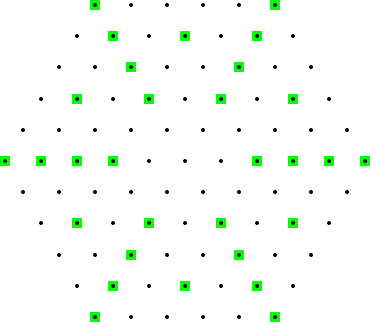
- Focus on the top right sixth of the orchard.
- We only need to count $\frac16$ of the orchard as it is symmetrical.
- The green points are the hidden ones.
- We can use angles to model the orchard and all directions from the centre.
    - Direction $0$: right
    - Direction $n+1$: $60^\circ$ counter-clockwise from direction $n$.
- Since angles $\frac12$ and $\frac24$ are the same angles, one point is behind the other.
- This way, the number of hidden points is the total amount of points minus the amount of points with coprime $i$ and $j$.
- The total number of points in a hexagonal lattice is $1+6(\frac{n(n+1)}2)=3n(n+1)+1$.
- The number of coprime points can be counted with the totient summatory function $\Phi(n) = \sum_{k=1}^n \phi(k)$
- Therefore, the total number of hidden points is $H(n)=3n(n+1)+1-6*\Phi(n)$.
    - This has to be fixed to make sure it is correct.

In [ ]:
# 351 Totient approach
# this uses a totient summatory function
def total_points(n): # we need to subtract 1 for the centre point
    return 3*n*(n+1)+1
def totient_summatory(n):
    total = 0
    for k in range(1, n + 1):
        total+=euler_phi(k)
    return total
def h(n):
    return total_points(n)-6*totient_summatory(n)-1
h(10^8)

a double loop over coprime pairs $(i, j)$ to count multiples. Mathematically, it relies on the fundamental identity connecting the totient function to coprime pairs via floor division:

$$H(n) = 1 + \sum_{i=1}^{\lfloor n/2 \rfloor} \sum_{\substack{j=1 \\ \gcd(i,j)=1}}^{\lfloor n/2 \rfloor - i} \left\lfloor \frac{n}{i+j} \right\rfloor$$

In [ ]:
# 351 Hexagonal Orchards(brute-force)
size=100
total=size-1
for i in range(1,size//2):
    prev=total
    for j in range(1,size//2-i+1):
        if gcd(i,j)==1:
            total+=size//(i+j)-1
    print(i,total-prev)
total*=6
total

#### PE 357

In [ ]:
test(1)

In [ ]:
def test(i):
    for j in range(2,isqrt(i)+1):
        if i%j==0 and not is_prime(j+i//j):
            return False
    return True
limit=10^8
lst=list(map(lambda x:x-1,prime_range(limit)))
count=0
for i in lst:
    count+=test(i)*i
count

#### PE 381

In [ ]:
# 381 (prime-k) factorial
def prime_mod(p):
    mod3=inverse_mod(p-2,p)
    mod4=mod3*inverse_mod(p-3,p)%p
    mod5=mod4*inverse_mod(p-4,p)%p
    return (mod3+mod4+mod5)%p
sum([prime_mod(p) for p in prime_range(5,10^8)])

#### PE 387

In [ ]:
# 387 Harshad Numbers
def harshad_number(num):
    return not num%sum(map(int,str(num)))
def right_truncatable_harshad_number(num):
    for _ in range(len(str(num))-1):
        if not harshad_number(num):
            return False
        num=int(str(num)[:-1])
    return True
def strong_number(num):
    return is_prime(num//sum(map(int,str(num))))
def strong_right_truncatable_harshad_prime(num):
    return is_prime(num) and right_truncatable_harshad_number(int(str(num)[:-1])) and strong_number(int(str(num)[:-1]))
s=set()
for i in range(10,100):
    if harshad_number(i): s.add(i)
for _ in range(11):
    for num in tuple(s):
        for digit in range(10):
            if harshad_number(int(str(num)+str(digit))): s.add(int(str(num)+str(digit)))
count=0
for num in sorted(s):
    if strong_number(num):
        for digit in range(10):
            if is_prime(int(str(num)+str(digit))):
                print(int(str(num)+str(digit)))
                count+=int(str(num)+str(digit))
count

## > 400

#### PE 401(unfinished)

In [ ]:
# 401 Sum of Squares of Divisors
# use sublinear number-theoretic summation
# up to 10^15
# += 10^15//num*num^2

#### PE 493

In [ ]:
def compute(i,j):
    ans=binomial(7,j)
    tot=10*j
    for k in range(i):
        ans*=(tot-k)/(70-k)
    return ans

In [ ]:
# 493 Under the Rainbow
p2=compute(20,2)
p3=compute(20,3)
p4=compute(20,4)
p5=compute(20,5)
p6=compute(20,6)
p7=1-p6
p6-=p5
p5-=p4
p4-=p3
p3-=p2
n(2*p2+3*p3+4*p4+5*p5+6*p6+7*p7)

In [ ]:
n(7*(1-binomial(60,20)/binomial(70,20)))

#### PE 500(add notes)

In [ ]:
num=nth_prime(500501)     # 500501th prime is 7376513
powered=[]
for i in [2,4,8,16,32]:
    lst=prime_range(2,ceil(num^(1/i)))
    powered+=[j^i for j in lst]
lst=sorted(set(prime_range(2,7376514)+powered))
lst=lst[:500500]
prod(lst)%500500507

#### PE 549(unfinished)

In [ ]:
# linear sieve
spf=list(range(10^8+10))
prime=[]
for i in range(2,10^8):
    if spf[i]==i:          # if there is no smaller prime factor
        prime.append(i)
    for p in prime:
        if i*p>=10^8:       # if prime is too big
            break
        spf[i*p]=p         # set as smallest prime factor
        if i%p==0:         # to make prime factor smallest
            break

In [ ]:
def v(p,m):
    sp=sum(ZZ(m).digits(base=p))
    return (m-sp)//(p-1)
def alter_find(num,times,lower=0):
    if times<=2:
        return times
    upper=num*times
    while lower+1!=upper:
        i=(lower+upper)//2
        if v(num,i)>=times:
            upper=i
        else:
            lower=i
    return lower-1
def min_div(m):
    if is_prime(m):
        return m
    elif m in div_memo:
        return div_memo[m]
    elif is_prime_power(m):
        lst=factor(m)[0]
        ans=alter_find(lst[0],lst[1])*lst[0]
        div_memo.update({m:ans})
        return ans
    num=spf[m]
    spp=num
    while m%spp==0:
        spp*=num
    spp//=num
    return max(min_div(spp),min_div(m//spp))
tot=0
for m in range(2,10^8+1):
    tot+=min_div(m)
tot

#### PE 587
- Use piecewise integration(left triangle and right circular triangle).
- Circle: $y=1-\sqrt{1-(x-1)^2}$

In [ ]:
# 587 Concave Triangle
def lsection(size):
    var('y')
    num=(1-pi/4)
    tri=solve([(x-1)^2+(y-1)^2==1,y==x/size],x,y)[0][0].rhs()*solve([(x-1)^2+(y-1)^2==1,y==x/size],x,y)[0][1].rhs()/2
    con=integral(1-sqrt(1-(x-1)^2),x,solve([(x-1)^2+(y-1)^2==1,y==x/size],x,y)[0][0].rhs(),1)
    return n((tri+con)/num*100)
lsection(2240)

#### PE 607

![image](https://www.mscha.org/tmp/pe607.png)
- To solve this problem, we use Snell's law.
    - $\large\frac{\sin{\theta_1}}{\sin{\theta_2}}=\frac{v_1}{v_2}$ where $\theta$ are the refraction angles and $v$ is the speed they travel at.
- First we rotate the viewpoint by $45^\circ$ so that the lightest marsh is at the top.
- Since $A$ and $B$ are $100$ leagues apart, when rotated, $B$ would be roughly $71$ leagues right and down.
    - Then we would be moving ~$10$ leagues down to enter the marsh and another $10$ after we exit it.
- We can calculate the initial refraction angle that will allow the fastest travel time from $A$ to $B$.
    - We can either calculate this, or we can use a binary search.

In [ ]:
# used binary search to find optimal angle
angle=57.28560916642072
angle*=pi/180
tomarsh=25*(sqrt(2)-1)
righttomarsh=tan(angle)*tomarsh
total=2*righttomarsh
angles=[]
for speed in range(9,4,-1):
    angle=arcsin(sin(angle)/(speed+1)*speed)
    angles.append(angle)
total+=sum([10*tan(angle) for angle in angles])
n(total-50*sqrt(2))

In [230]:
# 607 Marsh Crossing
# this calculates the actual time
angle=57.28560916642072
angle*=pi/180
tomarsh=25*(sqrt(2)-1)
righttomarsh=tan(angle)*tomarsh
disttomarsh=sqrt(righttomarsh^2+tomarsh^2)
time=disttomarsh/5
for speed in range(9,4,-1):
    angle=arcsin(sin(angle)/(speed+1)*speed)
    rightdist=10*tan(angle)
    time+=sqrt(10^2+rightdist^2)/speed
round(time,10)

13.1265108586

#### PE 650(unfinished)

In [ ]:
sigma(product(binomial(20000,x),x,1,20000))%(10^9+7)           # number too large, test only works up to 2000

#### PE 684(unfinished)

- There is a pattern after the first few outputs from the below cell.
    - Every number begins with $6111111...$
    - The next number is generated by adding a $1$ to the middle, then subtracting $10$.
    - These numbers can be generated easily using integer-string convertion.
    - Unfortuantely, these numbers have tons of digits.
    - Modular arithmetic?

In [ ]:
import sys
sys.setrecursionlimit(10^6)
memo={1:540,2:6030}
def inverse_digit_sum_sum(n):
    if n in memo: return memo[n]
    prev=str(inverse_digit_sum_sum(n-1))
    ans=int(prev[0]+'1'+prev[1:])
    ans-=10
    memo[n]=ans
    return ans
num=inverse_digit_sum_sum(fibonacci(22))%(10^9+7)

#### PE 686

In [ ]:
# 686 Powers of two
# check the 678910th line, after the space
num=128
pow=7
for _ in range(2*10^8):
    num*=2
    num=int(str(num)[:15])
    pow+=1
    if str(num)[:3]=='123':
        print(num,pow)

#### PE 700(unfinished)

In [ ]:
# 700 Eulercoin
seq=[1504170715041707]
for n in range(2,10000000):
    l=(1504170715041707*n) % 4503599627370517
    if l<seq[-1]:
        seq.append(l)
seq

#### PE 719
https://oeis.org/A104113
Optimize solution

In [ ]:
import requests
request=requests.get('https://oeis.org/A038206/b038206.txt')
content=request.text
lst=content.split('\n')
lst=lst[2:408]
lst=[line.split() for line in lst]
count=0
for l in lst:
    count+=int(l[1])^2
count

In [ ]:
# 719 Number Splitting
def splittings(digits):
    lst=[]
    temp=[]
    last_temp=[]
    while True:
        if last_temp==[]:
            temp=[[i] for i in range(1,digits+1)]
        else:
            for l in last_temp:
                for i in range(1,digits-sum(l)+2):
                    temp.append(l+[i])
        for l in temp:
            if sum(l)==digits:
                lst.append(l)
                temp.remove(l)
        if temp==[]:
            break
        last_temp=temp
        temp=[]
    return lst
splittings_dict={i:splittings(i) for i in range(2,13)}
def calculate(n,splitting):
    ans=0
    lst=list(str(n))
    for val in splitting:
        ans+=int(''.join(lst[:val]))
        lst=lst[val:]
    return ans
def is_s_number(n):
    s=set()
    for splitting in splittings_dict[len(str(n))]:
        s.add(calculate(n,splitting))
    return sqrt(n) in s
is_s_number(3025)

In [ ]:
num=0
for i in range(9,100000):
    if i%9 in [0,1]:
        if is_s_number(i^2):
            print(i^2)
            num+=i^2
num

In [ ]:
# 719 Number Splitting
splittings_dict={i:list(Partitions(i)) for i in range(2,13)}
def calculate(n,splitting):
    ans=0
    lst=list(str(n))
    for val in splitting:
        ans+=int(''.join(lst[:val]))
        lst=lst[val:]
    return ans
def is_s_number(n):
    s=set()
    for splitting in splittings_dict[len(str(n))]:
        s.add(calculate(n,splitting))
    return sqrt(n) in s
is_s_number(3025)

#### PE 751

In [ ]:
# 751 Concatenation Coincidence
def concatenation(theta):
    lst=[theta]
    for _ in range(20):
        lst.append(floor(lst[-1])*(lst[-1]-floor(lst[-1])+1))
    s=''
    for num in lst:
        s=s+str(floor(num))
    return s
concatenation(2.223561019313554106173177)

#### PE 757(unfinished)

In [ ]:
# 757 Stealthy numbers
# a,b,c,d, divisors of n exist such that a+b=c+d+1
# limit=10^14(too large for brute-force)
# number has to be divisible by 4

In [ ]:
# 757 Stealthy Numbers(brute-force)
for num in range(4,10^6,4):
    if not is_prime(num):
        lst=[]
        for divisor in divisors(num)[:ceil(len(divisors(num))/2)]:
            lst.append(divisor+num//divisor)
        for i in range(len(lst)-1):
            if lst[i]-lst[i+1]==1:
                print(factor(num))
                break

#### PE 788

In [ ]:
# 788 Dominating Numbers
count=0
for digits in range(1,2023):                                    # iterate up to 2022 digits
    for rep in range(digits//2+1,digits):                       # numbers are dominating if more than half digits equal
        count+=9*binomial(digits-1,rep-1)*9^(digits-rep)        # first, assume that the repeating one is not 0(nine choices)
        count+=9*binomial(digits-1,rep)*8*9^(digits-rep-1)      # use binomial coefficient for repeating digit placement
        count+=binomial(digits-1,rep)*9^(digits-rep)            # when counting 0, all remaining digits have 9 choices and 0 cannot be leading digit
    count+=9
    count%=10^9+7
    print(digits)
count

#### PE 800(unfinished)

In [ ]:
count=0
limit=log(800800^800800)
for i in prime_range(2,425000):
    print(i)
    num=floor(log(800800^800800,i))
    for j in range(num-10,num+1):
        if log(i^j*j^i)>limit:
            break
    count+=len(prime_range(i+1,j))
count

#### PE 808

In [ ]:
# 808 Reversible Prime Squares
def reverse(i):
    return int(str(i)[::-1])
def palindrome(i):
    return i==reverse(i)
limit=10^8
count=0
total=0
lst=prime_range(limit)
for i in lst:
    if not palindrome(i^2) and is_square(reverse(i^2)) and isqrt(reverse(i^2)) in lst:
        print(i^2)
        count+=1
        total+=i^2
        if count==50:
            break
total

#### PE 816

In [ ]:
import numpy as np
from scipy.spatial import cKDTree

# 1. Generate 1 million random 2D points
points = np.random.rand(2*10^6, 2)*50515093

# 2. Build the tree (This is the Divide & Conquer step)
tree = cKDTree(points)

# 3. Find the shortest distance among all points
# We query the nearest neighbor for every point (k=2 because k=1 is the point itself)
distances, indices = tree.query(points, k=2)

# 4. The shortest distance in the whole set
min_dist = distances[:, 1].min()

print(f"Shortest distance: {min_dist}")


In [ ]:
# 816 Shortest Distance Among Points
points=[]
num=290797
for _ in range(2000000):
    points.append((num,num^2%50515093))
    num=num^4%50515093
def distance(p1,p2):
    return (p2[0]-p1[0])^2+(p2[1]-p1[1])^2
def minimal_distance(lst):
    l=len(lst)
    record=10^10
    for i in range(l):
        for j in range(i):
            record=min(distance(lst[i],lst[j]),record)
    return record
lst=sorted(points)
sections=[[set() for _ in range(506)] for _ in range(506)]
for point in lst:
    sections[point[0]//100000][point[1]//100000].add(point)
record=10^6
for j in range(506):
    for i in range(len(sections[j])):
        record=min(minimal_distance(list(sections[j][i])),record)
    print(record)
n(sqrt(record),digits=9)

#### PE 820(unfinished)

In [ ]:
# 820 Nth Digit of Reciprocals
for i in range(1,10^4+1):
    old_i=i
    num=0
    while i%10==0:
        i//=10
        num+=1
    while i%2==0:
        i//=2
        num+=1
    while i%5==0:
        i//=5
        num+=1
    if i==1:
        continue
    print(old_i,10^((7%multiplicative_order(mod(10,i)))+num)//i%10)

#### PE 822(unfinished)

In [ ]:
# 822 Square the smallest
lst=list(range(2,10001))
for i in range(10^5):
    lst.sort()
    lst[0]=lst[0]^2
# sorted(lst)

#### PE 836
There isn't actually any code for this ;)

#### PE 872

In [ ]:
# Step 1: tree construction
memo={}
def tree(x):
    if x==1: return [[]]
    elif x in memo: return memo[x]
    tr=tree(x-1)
    longest_path=[x-1]
    while tr[longest_path[-1]-1]!=[]: longest_path.append(max(tr[longest_path[-1]-1]))
    ans=[]
    for i in range(x-1):
        ans.append(list(filter(lambda x:x not in longest_path,tr[i])))
    ans.append(longest_path[::-1])
    memo.update({x:ans})
    return ans

Step 2: Visual pattern recognition
- Step 1 generated 'towers' in the output(line $n$ is list of childs for node $n$).
- Each 'tower' had heights of powers of 2(except the leftmost one).
- The numbers in each 'tower' had numbers in order(smaller at the top).
- Therefore, the difference of the numbers at the bottom(childs of the root node) with the tree size/number of parent node would be power of 2.
- Using this, we can calculate the location of every number(parent node of every node).
- `tree(1000)[-17:]` shows this pattern for `path(10^3,9^3)`

In [ ]:
# Step 3: Applying pattern
def path(x,k):
    pos=x
    columns=ceil(log(x,2))
    bottom=[x-2^i for i in range(columns)][::-1]
    if k in bottom: return x+k
    for i,base in enumerate(bottom):
        if base>k:
            fl=x-(base-k)
            break
    return k+new_path(x,fl)
path(10^17,9^17)

#### PE 885(unfinished)

In [3]:
# 885 Sorted Digits
def non_decreasing(digits):
    pass

#### PE 918

In [ ]:
def a(n):
    if n==1:
        return 1
    elif n%2==0:
        return 2*a(n//2)
    i=(n-1)//2
    return a(i)-3*a(i+1)
4-3*a(5)

#### PE 940ing

In [ ]:
memo={}
def a(m,n):
    if m==0 and n==0:
        return 0
    elif m==0 and n==1:
        return 1
    elif (m,n) in memo:
        return memo[(m,n)]
    elif n!=0:
        pass

#### PE -1

In [ ]:
# Use ramanujan summation formula
s=-12


#### PE $\sqrt{13}$

In [ ]:
def root13_digit_sum(digits=1000):
    return sum(
        map(int,
            str(n(sqrt(13), digits=digits+5))  # +5 to be safe
            .replace('.', '')[1:digits+1]      # skip the integer part '3'
        )
    )
# root13_digit_sum(1000)

In [ ]:
# Bonus Problem
num=n(sqrt(13),digits=2000)
lst=list(str(num))
lst=lst[2:1002]
# sum(map(int,lst))

In [ ]:
list(continued_fraction(sqrt(13))[1:1003])

In [ ]:
bronze_ratio=1.5
for i in range(1,1000):
    bronze_ratio=3+1/bronze_ratio
bronze_ratio

#### PE Heegner

In [ ]:
def compute(j):
    ans=n(cosh(pi*sqrt(j)),10000)
    return (ans-floor(ans))*10^6

for i in range(2,1001):
    if not is_square(i):
        if n(compute(i))>999999.999999 or n(compute(i))<0.000001:
            print(n(compute(i)),i)

#### PE 18i - ing

In [ ]:
def r(p):
    return product(x^3-3*x+4,x,0,p-1)%p

for i in prime_range(1000):
    print(r(i))

In [ ]:
var('x')
(x^3-3*x+4).roots(ring=CC)

In [ ]:
lst=r_primes(30000)
lst=[i%12 for i in lst]
set(lst)-{2}-{3}

In [ ]:
def r_primes(p):
    primes=set()
    for i in range(p):
        lst=list(factor(i^3-3*i+4))
        for prime in lst:
            primes.add(prime[0])
    return sorted(primes)

r_primes(2*10^4)

In [ ]:
def r_prime(p):
    if p%12==1:
        pass
    elif p%12==5:
        pass
    return 0    

#### PE secret

In [ ]:
def mapping(i,j):
    if i!=0 and i!=5 and j!=0 and j!=9:
        return m[i-1][j]+m[i+1][j]+m[i][j-1]+m[i][j+1]
    elif i!=0 and i!=5 and j!=9:
        return m[i-1][j]+m[i+1][j]+m[i][-1]+m[i][1]
    elif i!=0 and i!=5 and j!=0:
        return m[i-1][j]+m[i+1][j]+m[i][-2]+m[i][0]
    elif i!=5 and j!=0 and j!=9:
        return m[-1][j]+m[1][j]+m[i][-1]+m[i][1]
    elif i!=0 and j!=0 and j!=9:
        return m[-2][j]+m[0][j]+m[i][-1]+m[i][1]
    elif i==0 and j==0:
        return m[0][1]+m[0][-1]+m[1][0]+m[-1][0]
    elif i==0 and j==9:
        return m[0][-2]+m[0][0]+m[1][-1]+m[-1][-1]
    elif i==5 and j==0:
        return m[-2][0]+m[0][0]+m[-1][1]+m[-1][-1]
    return m[-1][-2]+m[-2][-1]+m[-1][0]+m[0][-1]
m=[[0,0,0,0,0,0,0,0,0,4],
   [2,0,0,0,0,0,0,0,0,0],
   [1,5,0,0,0,0,0,0,0,3],
   [4,0,0,0,0,0,0,0,0,0],
   [0,0,0,0,0,0,0,0,0,2],
   [5,0,0,0,0,0,0,0,3,1]]
for _ in range(16):
    new_m=[[mapping(i,j)%7 for j in range(10)] for i in range(6)]
    m=new_m
m

In [ ]:
  dadafbcf
dcebcef  f
ec bfbecfa
bba deeddd
ccfbccceac
 fd fffdcc